# Análisis de Series Temporales
## Trabajo Final - Maestría en Ciencias de Datos
### Predicción de Cortes de Energía con Redes Neuronales - LSTM

**Materia:** Análisis de Series de Tiempo  
**Alumnos:** Arenas - Banegas - Marín - Zamora

---

## Resumen Ejecutivo

Este trabajo presenta un análisis predictivo de **cortes de energía eléctrica** utilizando Prophet. El dataset incluye:

- **Cortes:** Cantidad semanal de cortes de luz
- **Temp:** Temperatura media semanal (°C) — variable exógena
- **Hum:** Humedad relativa media semanal (%) — variable exógena

Se analiza la relación entre temperatura, humedad y cortes de luz para desarrollar un modelo predictivo

# 1. Marco teórico: LSTM

LSTM (Long Short-Term Memory)
Las redes LSTM son un tipo de red neuronal recurrente (RNN) diseñadas específicamente para aprender dependencias de largo plazo en secuencias temporales. A diferencia de las RNN tradicionales, que sufren el problema del gradiente evanescente al procesar secuencias largas, las LSTM incorporan un mecanismo de compuertas que regula qué información se retiene, qué se olvida y qué se transmite hacia adelante.
Este mecanismo opera a través de tres compuertas: la compuerta de olvido decide qué parte del estado interno se descarta; la compuerta de entrada determina qué información nueva se incorpora; y la compuerta de salida controla qué parte del estado interno se utiliza para generar la predicción. Este diseño permite que la red mantenga memoria selectiva sobre patrones relevantes a lo largo de horizontes temporales extensos.
En el contexto de series temporales, la LSTM recibe como entrada una ventana de observaciones pasadas y aprende a mapear esa secuencia hacia un valor futuro. A diferencia de los métodos estadísticos clásicos, no requiere supuestos sobre estacionariedad ni estructura paramétrica explícita, lo que la hace especialmente adecuada para series con patrones no lineales, estacionalidades complejas o alta variabilidad.


## 2. Configuración inicial

La arquitectura implementada consiste en una capa LSTM de 40 unidades seguida de una capa Dropout (0.20) para regularización y una capa densa de salida con una sola neurona. La red se entrena minimizando el error cuadrático medio (MSE) con el optimizador Adam.
El entrenamiento utiliza hasta 200 épocas con dos mecanismos de control: EarlyStopping con paciencia de 15 épocas que restaura los mejores pesos encontrados, y ReduceLROnPlateau que reduce la tasa de aprendizaje a la mitad cuando la pérdida de validación se estanca durante 5 épocas consecutivas. El 15% del conjunto de entrenamiento se reserva como validación interna para ambos callbacks.
La ventana de entrada es de 4 semanas (WINDOW_SIZE=4) y la predicción sobre el test se realiza de forma recursiva: en cada paso, la predicción generada reemplaza el valor de Cortes en la ventana, mientras que Temp y Hum se actualizan con los valores reales del período de test.

In [ ]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore", category=UserWarning)
tf.get_logger().setLevel("ERROR")

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [ ]:
SEED          = 42
TEST_FRAC     = 0.20
WINDOW_SIZE   = 4
RNN_UNITS     = 40
DROPOUT       = 0.20
LEARNING_RATE = 1e-3
BATCH_SIZE    = 16
EPOCHS        = 200
PATIENCE      = 15
TARGET_COL    = 'Cortes'
FEATURE_COLS  = ['Cortes', 'Temp', 'Hum']

np.random.seed(SEED)
tf.random.set_seed(SEED)


In [ ]:
# ── Carga de datos ───────────────────────────────────────────
df = pd.read_csv('completo.csv', parse_dates=['Semana'], index_col='Semana')
for col in ['Temp', 'Hum']:
    if df[col].dtype == object:
        df[col] = df[col].str.replace(',', '.', regex=False).astype(float)
df = df.asfreq('W-SUN').sort_index()

N       = len(df)
N_TRAIN = int(N * (1 - TEST_FRAC))
N_TEST  = N - N_TRAIN

train_df = df.iloc[:N_TRAIN]
test_df  = df.iloc[N_TRAIN:]
print(f"Train: {N_TRAIN} | Test: {N_TEST}")

Train: 209 | Test: 53


In [ ]:
# ── Helpers ──────────────────────────────────────────────────
def create_sequences(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:i + window_size])
        ys.append(y[i + window_size])
    return np.array(Xs), np.array(ys)

def build_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(RNN_UNITS, return_sequences=False),
        tf.keras.layers.Dropout(DROPOUT),
        tf.keras.layers.Dense(1),
    ])
    model.compile(
        loss='mse',
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        metrics=['mae'],
    )
    return model

def train_and_predict(X_train_s, y_train_s, X_test_s, y_test_real, n_features):
    """Entrena el modelo y predice recursivamente N_TEST pasos."""
    X_seq, y_seq = create_sequences(X_train_s, y_train_s, WINDOW_SIZE)

    model = build_model((WINDOW_SIZE, n_features))
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=PATIENCE,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=5, min_lr=1e-6
        ),
    ]
    history = model.fit(
        X_seq, y_seq,
        validation_split = 0.15,
        epochs           = EPOCHS,
        batch_size       = BATCH_SIZE,
        callbacks        = callbacks,
        verbose          = 0,
    )
    print(f"    Épocas: {len(history.history['loss'])}")

    # Predicción recursiva
    window  = list(X_train_s[-WINDOW_SIZE:])
    preds_s = []
    for step in range(N_TEST):
        x_in   = np.array(window[-WINDOW_SIZE:]).reshape(1, WINDOW_SIZE, -1)
        pred_s = model.predict(x_in, verbose=0)[0, 0]
        preds_s.append(pred_s)
        if step < len(X_test_s):
            next_row    = X_test_s[step].copy()
            next_row[0] = pred_s
        else:
            next_row    = window[-1].copy()
            next_row[0] = pred_s
        window.append(next_row)

    return np.array(preds_s), history, model


# Almacén de resultados
lstm_results = []   # lista de dicts para exportar



## 3. Modelado Univariado

Cada serie se modela de forma independiente utilizando únicamente su propia historia como input. La red recibe una ventana de 4 observaciones consecutivas de la variable objetivo y aprende a predecir el valor siguiente. Durante la inferencia, la predicción se realiza de forma recursiva sobre el período de test completo, actualizando la ventana con los valores predichos en cada paso.
Las series se estandarizan antes del entrenamiento (media 0, desvío 1) y las predicciones se llevan de vuelta a la escala original para calcular las métricas.


▶ Cortes
    Épocas: 18
    RMSE=7.9154  MAE=5.7116

▶ Temp
    Épocas: 134
    RMSE=7.9254  MAE=6.4557

▶ Hum
    Épocas: 69
    RMSE=15.2914  MAE=13.3174


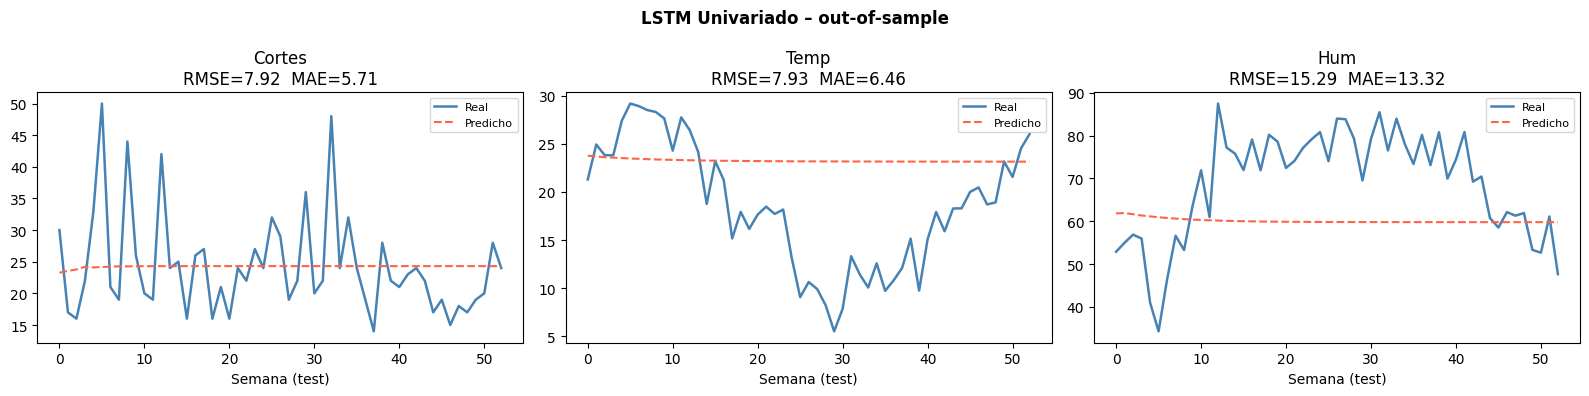

In [ ]:
SERIES_UNI = {
    'Cortes': df['Cortes'].values.astype(float),
    'Temp'  : df['Temp'].values.astype(float),
    'Hum'   : df['Hum'].values.astype(float),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('LSTM Univariado – out-of-sample', fontweight='bold')

for ax, (serie, arr) in zip(axes, SERIES_UNI.items()):
    print(f"\n▶ {serie}")

    y_train_arr = arr[:N_TRAIN]
    y_test_arr  = arr[N_TRAIN:]

    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_s = scaler_X.fit_transform(y_train_arr.reshape(-1, 1))
    y_train_s = scaler_y.fit_transform(y_train_arr.reshape(-1, 1)).ravel()
    X_test_s  = scaler_X.transform(y_test_arr.reshape(-1, 1))

    preds_s, history, _ = train_and_predict(
        X_train_s, y_train_s, X_test_s, y_test_arr, n_features=1
    )
    y_pred = scaler_y.inverse_transform(preds_s.reshape(-1, 1)).ravel()

    rmse_val = float(np.sqrt(mean_squared_error(y_test_arr, y_pred)))
    mae_val  = float(mean_absolute_error(y_test_arr, y_pred))
    print(f"    RMSE={rmse_val:.4f}  MAE={mae_val:.4f}")

    lstm_results.append({
        'model': 'LSTM_Uni', 'serie': serie,
        'date' : test_df.index,
        'y_true': y_test_arr, 'y_pred': y_pred,
        'rmse': round(rmse_val, 4), 'mae': round(mae_val, 4),
    })

    ax.plot(y_test_arr, label='Real',     color='steelblue', lw=1.8)
    ax.plot(y_pred,     label='Predicho', color='tomato',    lw=1.5, linestyle='--')
    ax.set_title(f'{serie}\nRMSE={rmse_val:.2f}  MAE={mae_val:.2f}')
    ax.set_xlabel('Semana (test)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('lstm_univariado.png', dpi=120, bbox_inches='tight')
plt.show()


Los tres modelos muestran el comportamiento típico de redes recurrentes en modo recursivo con datasets pequeños: las predicciones convergen rápidamente hacia la media de la serie, perdiendo sensibilidad a las fluctuaciones a medida que avanza el horizonte de predicción.
Cortes obtuvo RMSE=7.92 con apenas 18 épocas de entrenamiento, lo que indica que el EarlyStopping detuvo el proceso muy temprano — señal de que la red no encontró patrones adicionales más allá de la tendencia central. Temp requirió 134 épocas, lo que refleja una dinámica más compleja con la caída estacional visible en el gráfico, aunque el modelo tampoco logra capturarla completamente (RMSE=7.93). Hum nuevamente resulta la serie más difícil, con RMSE=15.29, consistente con su alta volatilidad y la incapacidad del modelo univariado de anticipar sus oscilaciones amplias.
Un dato relevante es que las 18 épocas de Cortes sugieren que con solo 4 lags y una arquitectura simple, la LSTM no dispone de suficiente información temporal para aprender patrones más ricos que el promedio histórico. Esto podría mejorarse aumentando WINDOW_SIZE o incorporando variables exógenas, lo que se evalúa en el modelo multivariado.

# 4. Modelado Multivariado

En el enfoque multivariado, la red recibe en cada paso temporal los valores de las tres variables simultáneamente: Cortes, Temp y Hum. El vector de entrada pasa de 1 feature a 3 features por paso temporal, manteniendo la misma ventana de 4 semanas. Durante la predicción recursiva, el valor de Cortes se actualiza con la predicción generada en cada paso, mientras que Temp y Hum se alimentan con los valores reales del período de test, aprovechando que estas variables son observables en el momento de predecir.

    Épocas: 16
  RMSE=7.9068  MAE=5.6921


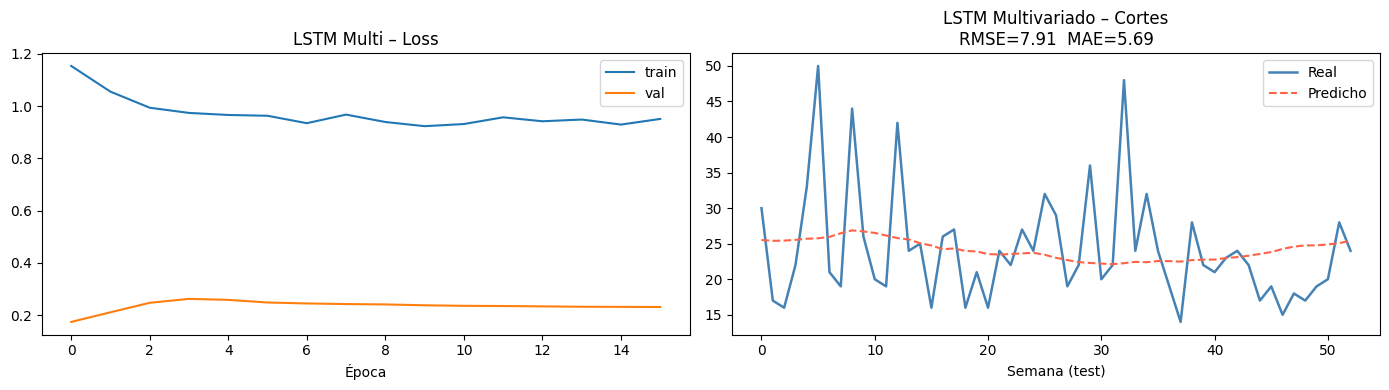

In [ ]:
FEATURE_COLS = ['Cortes', 'Temp', 'Hum']

X_train_raw = train_df[FEATURE_COLS].values
y_train_raw = train_df['Cortes'].values.astype(float)
X_test_raw  = test_df[FEATURE_COLS].values
y_test_raw  = test_df['Cortes'].values.astype(float)

scaler_Xm = StandardScaler()
scaler_ym = StandardScaler()

X_train_ms = scaler_Xm.fit_transform(X_train_raw)
y_train_ms = scaler_ym.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
X_test_ms  = scaler_Xm.transform(X_test_raw)

preds_ms, history_m, _ = train_and_predict(
    X_train_ms, y_train_ms, X_test_ms, y_test_raw, n_features=3
)
y_pred_m = scaler_ym.inverse_transform(preds_ms.reshape(-1, 1)).ravel()

rmse_m = float(np.sqrt(mean_squared_error(y_test_raw, y_pred_m)))
mae_m  = float(mean_absolute_error(y_test_raw, y_pred_m))
print(f"  RMSE={rmse_m:.4f}  MAE={mae_m:.4f}")

lstm_results.append({
    'model': 'LSTM_Multi', 'serie': 'Cortes (Temp+Hum)',
    'date' : test_df.index,
    'y_true': y_test_raw, 'y_pred': y_pred_m,
    'rmse': round(rmse_m, 4), 'mae': round(mae_m, 4),
})

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_m.history['loss'],     label='train')
axes[0].plot(history_m.history['val_loss'], label='val')
axes[0].set_title('LSTM Multi – Loss')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(y_test_raw, label='Real',     color='steelblue', lw=1.8)
axes[1].plot(y_pred_m,   label='Predicho', color='tomato',    lw=1.5, linestyle='--')
axes[1].set_title(f'LSTM Multivariado – Cortes\nRMSE={rmse_m:.2f}  MAE={mae_m:.2f}')
axes[1].set_xlabel('Semana (test)')
axes[1].legend()
plt.tight_layout()
plt.savefig('lstm_multivariado.png', dpi=120, bbox_inches='tight')
plt.show()



El modelo multivariado obtuvo RMSE=7.91 y MAE=5.69, una mejora marginal respecto al univariado de Cortes (RMSE=7.92). La diferencia es prácticamente insignificante, lo que sugiere que la incorporación de Temp y Hum no aporta información adicional sustancial para la predicción en este horizonte.
La curva de loss revela un problema relevante: la pérdida de validación se estabiliza muy temprano (alrededor de la época 3) mientras que la pérdida de entrenamiento continúa descendiendo lentamente durante las 15 épocas registradas. Esta brecha entre train y val loss indica que el modelo tiene dificultades para generalizar, probablemente debido al tamaño reducido del conjunto de entrenamiento disponible para una arquitectura recurrente.
Visualmente, el comportamiento es análogo al univariado: predicciones suavizadas alrededor de la media, sin capacidad de anticipar los picos extremos de la serie. La ligera curvatura ascendente al final del período de test es el único rasgo diferencial respecto al univariado, posiblemente influenciada por los valores de Temp y Hum del verano de 2025.

## 5.Guardado final

Guardado final: Se exportan las predicciones del conjunto de test (20% final) para cada serie: modelos univariados (Cortes, Temp, Hum) y el modelo multivariado (Cortes ~ Temp + Hum). Incluye valores reales (y_true), predicciones (y_pred) y métricas (RMSE, MAE).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
BASE_PATH = "/content/drive/MyDrive/SDT/Resultados"
os.makedirs(BASE_PATH, exist_ok=True)

Mounted at /content/drive


In [ ]:
all_preds   = []
all_metrics = []

for r in lstm_results:
    df_pred = pd.DataFrame({
        'model' : r['model'],
        'serie' : r['serie'],
        'date'  : r['date'],
        'y_true': r['y_true'],
        'y_pred': r['y_pred'],
    })
    all_preds.append(df_pred)
    all_metrics.append({
        'model': r['model'],
        'serie': r['serie'],
        'rmse' : r['rmse'],
        'mae'  : r['mae'],
    })

pd.concat(all_preds).to_csv(
    f"{BASE_PATH}/predictions_LSTM.csv", index=False)
pd.DataFrame(all_metrics).to_csv(
    f"{BASE_PATH}/metrics_LSTM.csv", index=False)

print("\n✔ LSTM guardado correctamente")
print(pd.DataFrame(all_metrics))


✔ LSTM guardado correctamente
        model              serie     rmse      mae
0    LSTM_Uni             Cortes   7.9298   5.7285
1    LSTM_Uni               Temp   5.7406   4.6899
2    LSTM_Uni                Hum  12.5247  11.0524
3  LSTM_Multi  Cortes (Temp+Hum)   8.1367   6.1649
